# Verify Assistant Axis Vector Consistency

Simple verification that the pre-computed vectors satisfy the expected mathematical relationships:

1. **Formula check**: `default_vector ≈ mean(role_vectors) + assistant_axis`
2. **Axis definition check**: `assistant_axis ≈ default_vector - mean(role_vectors)`

Both should hold with < 1% relative error.

In [1]:
import numpy as np
import torch
from pathlib import Path
from huggingface_hub import snapshot_download

/Users/irakl/Desktop/Projects/LASR/persona-shattering-lasr/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

In [2]:
# Model to analyze
MODEL_NAME = "gemma-2-27b"  # Options: "gemma-2-27b", "llama-3.3-70b", "qwen-3-32b"
TARGET_LAYER = 22  # Recommended layers: Gemma=22, LLaMA=40, Qwen=32

# HuggingFace dataset
REPO_ID = "lu-christina/assistant-axis-vectors"

print(f"Model: {MODEL_NAME}")
print(f"Target layer: {TARGET_LAYER}")

Model: gemma-2-27b
Target layer: 22


## Download Vectors from HuggingFace

In [3]:
# Download all vectors
print(f"Downloading vectors from {REPO_ID}...")
local_dir = snapshot_download(
    repo_id=REPO_ID,
    repo_type="dataset",
    allow_patterns=[
        f"{MODEL_NAME}/role_vectors/*.pt",
        f"{MODEL_NAME}/default_vector.pt",
        f"{MODEL_NAME}/assistant_axis.pt",
    ]
)
print(f"✓ Downloaded to: {local_dir}")

Fetching ... files: 277it [00:00, 428084.82it/s]

✓ Downloaded to: /Users/irakl/.cache/huggingface/hub/datasets--lu-christina--assistant-axis-vectors/snapshots/3b3b788432ad33e3a28d9ff08e88a530c0740814


## Load Vectors

In [4]:
# Load role vectors
role_vectors_dir = Path(local_dir) / MODEL_NAME / "role_vectors"
role_vectors_list = []

for pt_file in sorted(role_vectors_dir.glob("*.pt")):
    vec = torch.load(pt_file, map_location="cpu", weights_only=False)
    role_vectors_list.append(vec[TARGET_LAYER])

role_vectors = torch.stack(role_vectors_list).float().numpy()  # (n_roles, n_features)
print(f"✓ Loaded {len(role_vectors)} role vectors: {role_vectors.shape}")

# Load default vector
default_vector_path = Path(local_dir) / MODEL_NAME / "default_vector.pt"
default_vector = torch.load(default_vector_path, map_location="cpu", weights_only=False)
default_vector = default_vector[TARGET_LAYER].float().numpy()  # (n_features,)
print(f"✓ Loaded default vector: {default_vector.shape}")

# Load assistant axis
assistant_axis_path = Path(local_dir) / MODEL_NAME / "assistant_axis.pt"
assistant_axis = torch.load(assistant_axis_path, map_location="cpu", weights_only=False)
assistant_axis = assistant_axis[TARGET_LAYER].float().numpy()  # (n_features,)
print(f"✓ Loaded assistant axis: {assistant_axis.shape}")

✓ Loaded 275 role vectors: (275, 4608)
✓ Loaded default vector: (4608,)
✓ Loaded assistant axis: (4608,)


## Verification Tests

In [5]:
print("=" * 60)
print("VERIFICATION: Vector Consistency Checks")
print("=" * 60)

# Compute mean of role vectors
mean_roles = role_vectors.mean(axis=0)

print(f"\nVector norms:")
print(f"  default_vector:   {np.linalg.norm(default_vector):.2f}")
print(f"  assistant_axis:   {np.linalg.norm(assistant_axis):.2f}")
print(f"  mean(roles):      {np.linalg.norm(mean_roles):.2f}")

# ============================================
# TEST 1: Vector arithmetic check
# ============================================
print("\n" + "=" * 60)
print("TEST 1: Formula Check")
print("Expected: default_vector ≈ mean(roles) + assistant_axis")
print("=" * 60)

computed_default = mean_roles + assistant_axis
error = default_vector - computed_default
formula_error = np.linalg.norm(error) / np.linalg.norm(default_vector) * 100

print(f"\nComputed (mean + axis) norm: {np.linalg.norm(computed_default):.2f}")
print(f"Difference norm:              {np.linalg.norm(error):.6f}")
print(f"Relative error:               {formula_error:.6f}%")

if formula_error < 1.0:
    print("\n✓ PASS: Formula holds (error < 1%)")
else:
    print("\n✗ FAIL: Formula does not hold (error >= 1%)")

# ============================================
# TEST 2: Axis definition check
# ============================================
print("\n" + "=" * 60)
print("TEST 2: Axis Definition Check")
print("Expected: assistant_axis ≈ default_vector - mean(roles)")
print("=" * 60)

computed_axis = default_vector - mean_roles
axis_diff = computed_axis - assistant_axis
axis_error = np.linalg.norm(axis_diff) / np.linalg.norm(assistant_axis) * 100

print(f"\nComputed (default - mean) norm: {np.linalg.norm(computed_axis):.2f}")
print(f"Difference norm:                 {np.linalg.norm(axis_diff):.6f}")
print(f"Relative error:                  {axis_error:.6f}%")

if axis_error < 1.0:
    print("\n✓ PASS: Axis definition is consistent (error < 1%)")
else:
    print("\n✗ FAIL: Axis definition is inconsistent (error >= 1%)")

# ============================================
# SUMMARY
# ============================================
print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)

if formula_error < 1.0 and axis_error < 1.0:
    print("\n✓ ALL TESTS PASSED")
    print("  The vectors are mathematically consistent.")
    print("  The formula: axis = mean(default) - mean(roles) holds.")
else:
    print("\n✗ SOME TESTS FAILED")
    print("  The vectors may have been computed with different data or methods.")

print(f"\nFormula error:     {formula_error:.6f}%")
print(f"Axis error:        {axis_error:.6f}%")

VERIFICATION: Vector Consistency Checks

Vector norms:
  default_vector:   16326.44
  assistant_axis:   780.69
  mean(roles):      15860.69

TEST 1: Formula Check
Expected: default_vector ≈ mean(roles) + assistant_axis

Computed (mean + axis) norm: 16306.54
Difference norm:              21.060341
Relative error:               0.128995%

✓ PASS: Formula holds (error < 1%)

TEST 2: Axis Definition Check
Expected: assistant_axis ≈ default_vector - mean(roles)

Computed (default - mean) norm: 792.94
Difference norm:                 21.060341
Relative error:                  2.697674%

✗ FAIL: Axis definition is inconsistent (error >= 1%)

SUMMARY

✗ SOME TESTS FAILED
  The vectors may have been computed with different data or methods.

Formula error:     0.128995%
Axis error:        2.697674%


## Test All Models

In [6]:
def verify_model(model_name: str, target_layer: int, local_dir: str) -> dict:
    """Verify vector consistency for a given model."""
    # Load vectors
    role_vectors_dir = Path(local_dir) / model_name / "role_vectors"
    role_vectors_list = []
    
    for pt_file in sorted(role_vectors_dir.glob("*.pt")):
        vec = torch.load(pt_file, map_location="cpu", weights_only=False)
        role_vectors_list.append(vec[target_layer])
    
    role_vectors = torch.stack(role_vectors_list).float().numpy()
    
    default_vector_path = Path(local_dir) / model_name / "default_vector.pt"
    default_vector = torch.load(default_vector_path, map_location="cpu", weights_only=False)
    default_vector = default_vector[target_layer].float().numpy()
    
    assistant_axis_path = Path(local_dir) / model_name / "assistant_axis.pt"
    assistant_axis = torch.load(assistant_axis_path, map_location="cpu", weights_only=False)
    assistant_axis = assistant_axis[target_layer].float().numpy()
    
    # Compute errors
    mean_roles = role_vectors.mean(axis=0)
    
    # Formula error
    computed_default = mean_roles + assistant_axis
    error = default_vector - computed_default
    formula_error = np.linalg.norm(error) / np.linalg.norm(default_vector) * 100
    
    # Axis error
    computed_axis = default_vector - mean_roles
    axis_diff = computed_axis - assistant_axis
    axis_error = np.linalg.norm(axis_diff) / np.linalg.norm(assistant_axis) * 100
    
    return {
        'model': model_name,
        'layer': target_layer,
        'n_roles': len(role_vectors),
        'formula_error': formula_error,
        'axis_error': axis_error,
        'passed': formula_error < 1.0 and axis_error < 1.0,
    }

In [7]:
# Download all models
print("Downloading all model vectors...\n")

for model_name in ["gemma-2-27b", "llama-3.3-70b", "qwen-3-32b"]:
    snapshot_download(
        repo_id=REPO_ID,
        repo_type="dataset",
        allow_patterns=[
            f"{model_name}/role_vectors/*.pt",
            f"{model_name}/default_vector.pt",
            f"{model_name}/assistant_axis.pt",
        ]
    )
    print(f"  ✓ {model_name}")

print(f"\n✓ All vectors downloaded to: {local_dir}")

Fetching ... files: 277it [00:00, 277218.37it/s]


  ✓ gemma-2-27b


Fetching ... files: 277it [00:00, 685845.46it/s]


  ✓ llama-3.3-70b


Fetching ... files: 277it [00:00, 917711.06it/s]

  ✓ qwen-3-32b

✓ All vectors downloaded to: /Users/irakl/.cache/huggingface/hub/datasets--lu-christina--assistant-axis-vectors/snapshots/3b3b788432ad33e3a28d9ff08e88a530c0740814


In [8]:
# Verify all models
print("=" * 80)
print("VERIFICATION: All Models")
print("=" * 80)

models_config = [
    ("gemma-2-27b", 22),
    ("llama-3.3-70b", 40),
    ("qwen-3-32b", 32),
]

results = []
for model_name, layer in models_config:
    print(f"\n{model_name.upper()} (Layer {layer})")
    result = verify_model(model_name, layer, local_dir)
    results.append(result)
    
    print(f"  Formula error: {result['formula_error']:.6f}% {'✓' if result['formula_error'] < 1.0 else '✗'}")
    print(f"  Axis error:    {result['axis_error']:.6f}% {'✓' if result['axis_error'] < 1.0 else '✗'}")
    print(f"  Status:        {'PASS ✓' if result['passed'] else 'FAIL ✗'}")

# Summary
print("\n" + "=" * 80)
print("SUMMARY")
print("=" * 80)

passed = sum(1 for r in results if r['passed'])
total = len(results)

print(f"\n{passed}/{total} models passed all verification tests")

if passed == total:
    print("\n✓ ALL MODELS VERIFIED")
    print("  The HuggingFace vectors are mathematically consistent.")
else:
    print(f"\n⚠ {total - passed} model(s) failed verification")
    print("  Check the errors above for details.")

VERIFICATION: All Models

GEMMA-2-27B (Layer 22)
  Formula error: 0.128995% ✓
  Axis error:    2.697674% ✗
  Status:        FAIL ✗

LLAMA-3.3-70B (Layer 40)
  Formula error: 0.165779% ✓
  Axis error:    0.788441% ✓
  Status:        PASS ✓

QWEN-3-32B (Layer 32)
  Formula error: 0.254045% ✓
  Axis error:    1.867436% ✗
  Status:        FAIL ✗

SUMMARY

1/3 models passed all verification tests

⚠ 2 model(s) failed verification
  Check the errors above for details.


Checking loaded variables...
✓ role_vectors: (275, 4608)
✓ default_vector: (4608,)
✓ assistant_axis: (4608,)

1. Centering data...
2. Fitting PCA...
3. Computing projections...
4. Creating plot...



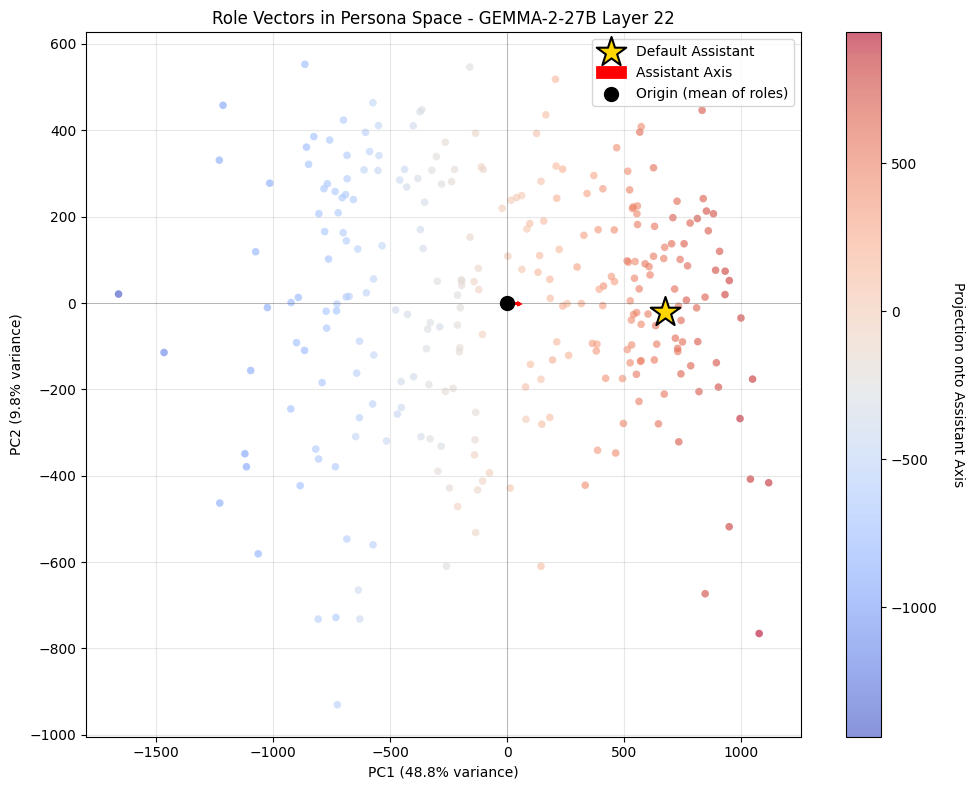

PCA DIAGNOSTICS
PC1 variance: 48.8%
PC2 variance: 9.8%
PC3 variance: 7.0%

Default Assistant PC coordinates: (674.28, -21.29, 65.78)
Assistant Axis PC direction (normalized): (0.994, -0.038, 0.099)

Cosine similarity between Assistant Axis and PC1: 0.994
✓ HIGH alignment - Assistant Axis aligns with PC1

Interpretation:
  - Roles colored BLUE have negative projections (more role-playing)
  - Roles colored RED have positive projections (more assistant-like)
  - The default assistant should be in the RED region


In [15]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Verify the variables exist and have the correct shape
print("Checking loaded variables...")
try:
    print(f"✓ role_vectors: {role_vectors.shape}")
    print(f"✓ default_vector: {default_vector.shape}")
    print(f"✓ assistant_axis: {assistant_axis.shape}")
except NameError as e:
    print(f"✗ Error: {e}")
    print("Please run the earlier cells to load the data first!")
    raise

# These variables are from cell 7:
# - role_vectors: (275, 4608) numpy array
# - default_vector: (4608,) numpy array
# - assistant_axis: (4608,) numpy array

# 1. Standardize (center by subtracting mean across roles)
print("\n1. Centering data...")
scaler = StandardScaler(with_std=False)  # Only centering, no scaling
scaler.fit(role_vectors)
role_vectors_centered = scaler.transform(role_vectors)
default_centered = scaler.transform(default_vector.reshape(1, -1))[0]
# Note: assistant_axis is already a difference vector, so we don't center it
assistant_axis_centered = assistant_axis

# 2. PCA to get top 3 components
print("2. Fitting PCA...")
pca = PCA(n_components=3)
role_vectors_pc = pca.fit_transform(role_vectors_centered)
default_pc = pca.transform(default_centered.reshape(1, -1))[0]

# Transform assistant axis to PC space
assistant_axis_pc = pca.transform(assistant_axis_centered.reshape(1, -1))[0]
assistant_axis_pc_normalized = assistant_axis_pc / np.linalg.norm(assistant_axis_pc)

# 3. Compute projections of each role onto the Assistant Axis (in original space)
print("3. Computing projections...")
projections = role_vectors_centered @ assistant_axis_centered / np.linalg.norm(assistant_axis_centered)

# 4. Create the plot (2D: PC1 vs PC2)
print("4. Creating plot...\n")
fig, ax = plt.subplots(figsize=(10, 8))

# Scatter role vectors, colored by projection
scatter = ax.scatter(
    role_vectors_pc[:, 0], 
    role_vectors_pc[:, 1],
    c=projections,
    cmap='coolwarm',  # Blue (negative, toward roles) to Red (positive, toward assistant)
    s=30,
    alpha=0.6,
    edgecolors='none'
)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Projection onto Assistant Axis', rotation=270, labelpad=20)

# Plot default assistant
ax.scatter(
    default_pc[0], 
    default_pc[1],
    marker='*',
    s=500,
    c='gold',
    edgecolors='black',
    linewidths=1.5,
    label='Default Assistant',
    zorder=5
)

# Draw Assistant Axis as arrow from origin
axis_scale = 50  # Adjust this to make arrow visible
ax.arrow(
    0, 0,
    assistant_axis_pc_normalized[0] * axis_scale,
    assistant_axis_pc_normalized[1] * axis_scale,
    head_width=3,
    head_length=5,
    fc='red',
    ec='red',
    linewidth=2,
    label='Assistant Axis',
    zorder=4
)

# Mark origin
ax.scatter(0, 0, marker='o', s=100, c='black', label='Origin (mean of roles)', zorder=5)

# Labels and legend
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title(f'Role Vectors in Persona Space - {MODEL_NAME.upper()} Layer {TARGET_LAYER}')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linewidth=0.5, alpha=0.3)
ax.axvline(x=0, color='k', linewidth=0.5, alpha=0.3)

plt.tight_layout()
plt.show()

# 5. Print diagnostics
print("=" * 60)
print("PCA DIAGNOSTICS")
print("=" * 60)
print(f"PC1 variance: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"PC2 variance: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"PC3 variance: {pca.explained_variance_ratio_[2]*100:.1f}%")
print(f"\nDefault Assistant PC coordinates: ({default_pc[0]:.2f}, {default_pc[1]:.2f}, {default_pc[2]:.2f})")
print(f"Assistant Axis PC direction (normalized): ({assistant_axis_pc_normalized[0]:.3f}, {assistant_axis_pc_normalized[1]:.3f}, {assistant_axis_pc_normalized[2]:.3f})")

# Check alignment with PC1
pc1_axis_cosine = assistant_axis_pc_normalized[0]  # Cosine with [1,0,0]
print(f"\nCosine similarity between Assistant Axis and PC1: {pc1_axis_cosine:.3f}")
if abs(pc1_axis_cosine) > 0.71:
    print("✓ HIGH alignment - Assistant Axis aligns with PC1")
else:
    print("⚠ LOW alignment - Assistant Axis does NOT align well with PC1")
    
print("\nInterpretation:")
print(f"  - Roles colored BLUE have negative projections (more role-playing)")
print(f"  - Roles colored RED have positive projections (more assistant-like)")
print(f"  - The default assistant should be in the RED region")

VISUALIZING ALL MODELS

Loading GEMMA-2-27B (Layer 22)
✓ Loaded 275 role vectors: (275, 4608)


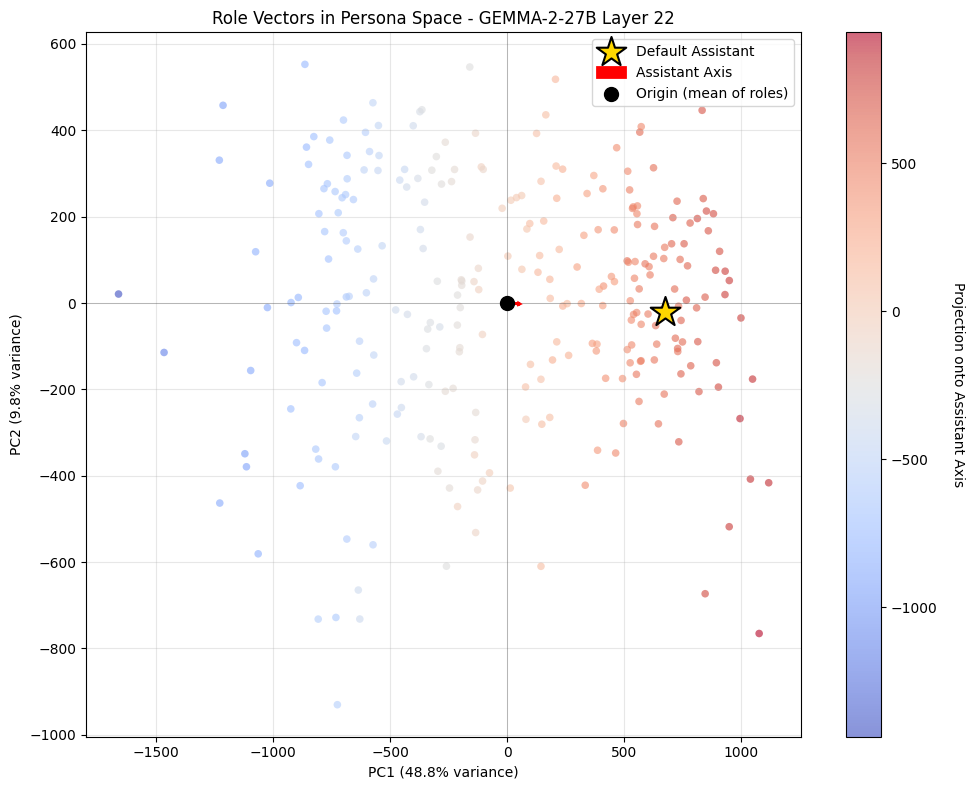


PC1 variance: 48.8%
PC2 variance: 9.8%
PC3 variance: 7.0%
Default PC: (674.28, -21.29, 65.78)
Axis PC (normalized): (0.994, -0.038, 0.099)
PC1↔Axis cosine: 0.994 ✓ HIGH

Loading LLAMA-3.3-70B (Layer 40)
✓ Loaded 275 role vectors: (275, 8192)


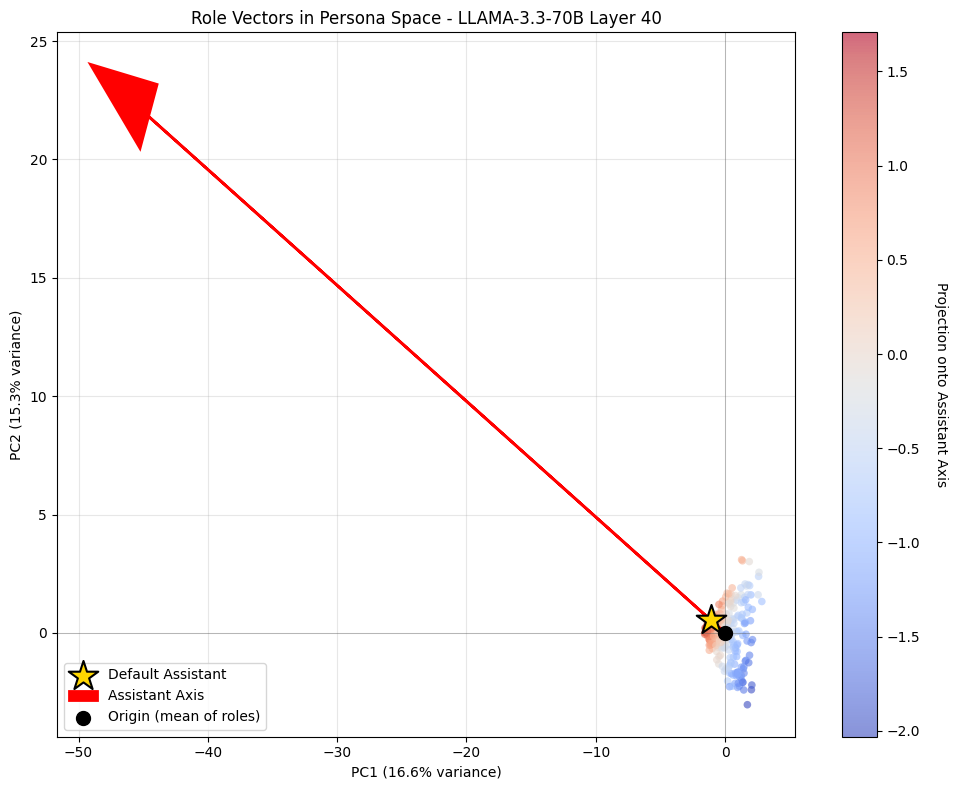


PC1 variance: 16.6%
PC2 variance: 15.3%
PC3 variance: 6.6%
Default PC: (-1.07, 0.53, -0.14)
Axis PC (normalized): (-0.892, 0.436, -0.120)
PC1↔Axis cosine: -0.892 ✓ HIGH

Loading QWEN-3-32B (Layer 32)
✓ Loaded 275 role vectors: (275, 5120)


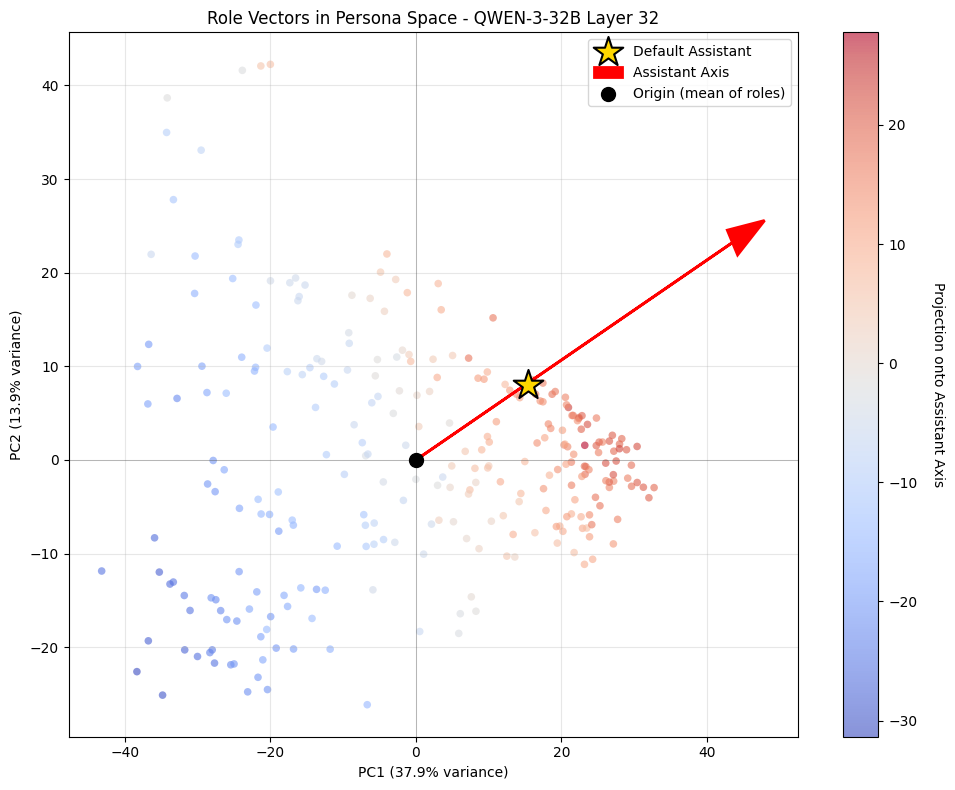


PC1 variance: 37.9%
PC2 variance: 13.9%
PC3 variance: 6.9%
Default PC: (15.40, 8.02, -2.91)
Axis PC (normalized): (0.870, 0.464, -0.167)
PC1↔Axis cosine: 0.870 ✓ HIGH


In [16]:
def plot_model_persona_space(model_name: str, target_layer: int, local_dir: str):
    """Create persona space visualization for a given model."""
    import matplotlib.pyplot as plt
    from sklearn.preprocessing import StandardScaler
    from sklearn.decomposition import PCA
    
    print(f"\n{'='*60}")
    print(f"Loading {model_name.upper()} (Layer {target_layer})")
    print('='*60)
    
    # Load vectors
    role_vectors_dir = Path(local_dir) / model_name / "role_vectors"
    role_vectors_list = []
    
    for pt_file in sorted(role_vectors_dir.glob("*.pt")):
        vec = torch.load(pt_file, map_location="cpu", weights_only=False)
        role_vectors_list.append(vec[target_layer])
    
    role_vectors = torch.stack(role_vectors_list).float().numpy()
    
    default_vector_path = Path(local_dir) / model_name / "default_vector.pt"
    default_vector = torch.load(default_vector_path, map_location="cpu", weights_only=False)
    default_vector = default_vector[target_layer].float().numpy()
    
    assistant_axis_path = Path(local_dir) / model_name / "assistant_axis.pt"
    assistant_axis = torch.load(assistant_axis_path, map_location="cpu", weights_only=False)
    assistant_axis = assistant_axis[target_layer].float().numpy()
    
    print(f"✓ Loaded {len(role_vectors)} role vectors: {role_vectors.shape}")
    
    # 1. Center data
    scaler = StandardScaler(with_std=False)
    scaler.fit(role_vectors)
    role_vectors_centered = scaler.transform(role_vectors)
    default_centered = scaler.transform(default_vector.reshape(1, -1))[0]
    assistant_axis_centered = assistant_axis
    
    # 2. Fit PCA
    pca = PCA(n_components=3)
    role_vectors_pc = pca.fit_transform(role_vectors_centered)
    default_pc = pca.transform(default_centered.reshape(1, -1))[0]
    assistant_axis_pc = pca.transform(assistant_axis_centered.reshape(1, -1))[0]
    assistant_axis_pc_normalized = assistant_axis_pc / np.linalg.norm(assistant_axis_pc)
    
    # 3. Compute projections
    projections = role_vectors_centered @ assistant_axis_centered / np.linalg.norm(assistant_axis_centered)
    
    # 4. Create plot
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Scatter role vectors
    scatter = ax.scatter(
        role_vectors_pc[:, 0], 
        role_vectors_pc[:, 1],
        c=projections,
        cmap='coolwarm',
        s=30,
        alpha=0.6,
        edgecolors='none'
    )
    
    # Colorbar
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Projection onto Assistant Axis', rotation=270, labelpad=20)
    
    # Default assistant
    ax.scatter(
        default_pc[0], 
        default_pc[1],
        marker='*',
        s=500,
        c='gold',
        edgecolors='black',
        linewidths=1.5,
        label='Default Assistant',
        zorder=5
    )
    
    # Assistant axis arrow
    axis_scale = 50
    ax.arrow(
        0, 0,
        assistant_axis_pc_normalized[0] * axis_scale,
        assistant_axis_pc_normalized[1] * axis_scale,
        head_width=3,
        head_length=5,
        fc='red',
        ec='red',
        linewidth=2,
        label='Assistant Axis',
        zorder=4
    )
    
    # Origin
    ax.scatter(0, 0, marker='o', s=100, c='black', label='Origin (mean of roles)', zorder=5)
    
    # Labels
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
    ax.set_title(f'Role Vectors in Persona Space - {model_name.upper()} Layer {target_layer}')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='k', linewidth=0.5, alpha=0.3)
    ax.axvline(x=0, color='k', linewidth=0.5, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Diagnostics
    print(f"\nPC1 variance: {pca.explained_variance_ratio_[0]*100:.1f}%")
    print(f"PC2 variance: {pca.explained_variance_ratio_[1]*100:.1f}%")
    print(f"PC3 variance: {pca.explained_variance_ratio_[2]*100:.1f}%")
    print(f"Default PC: ({default_pc[0]:.2f}, {default_pc[1]:.2f}, {default_pc[2]:.2f})")
    print(f"Axis PC (normalized): ({assistant_axis_pc_normalized[0]:.3f}, {assistant_axis_pc_normalized[1]:.3f}, {assistant_axis_pc_normalized[2]:.3f})")
    
    pc1_axis_cosine = assistant_axis_pc_normalized[0]
    print(f"PC1↔Axis cosine: {pc1_axis_cosine:.3f} {'✓ HIGH' if abs(pc1_axis_cosine) > 0.71 else '⚠ LOW'}")
    
    return {
        'pca': pca,
        'projections': projections,
        'pc1_axis_cosine': pc1_axis_cosine,
    }


# Plot all three models
models_config = [
    ("gemma-2-27b", 22),
    ("llama-3.3-70b", 40),
    ("qwen-3-32b", 32),
]

print("="*80)
print("VISUALIZING ALL MODELS")
print("="*80)

model_results = {}
for model_name, layer in models_config:
    result = plot_model_persona_space(model_name, layer, local_dir)
    model_results[model_name] = result